=== Loading images ===

===== 2D Vergleich: Prop(53→4.5m) vs Real(500cm) =====

[Original (old dx, no pad, peak->power)]
  ALL : MAE=3.839e-07, RMSE=6.343e-07, Max|Δ|=4.816e-06, relL2=0.4239, Corr=0.928
  BEAM: MAE=5.333e-07, RMSE=7.498e-07, Max|Δ|=4.816e-06, relL2=0.4239, Corr=0.9228


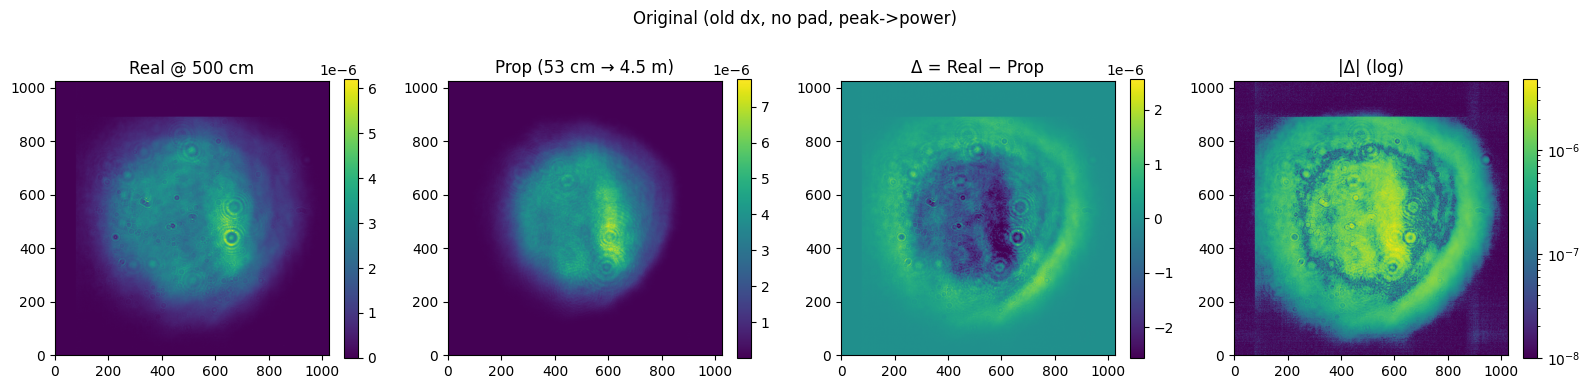


[Correct dx (no pad)]
  ALL : MAE=3.839e-07, RMSE=6.345e-07, Max|Δ|=5.062e-06, relL2=0.424, Corr=0.928
  BEAM: MAE=5.331e-07, RMSE=7.499e-07, Max|Δ|=5.062e-06, relL2=0.4239, Corr=0.9227


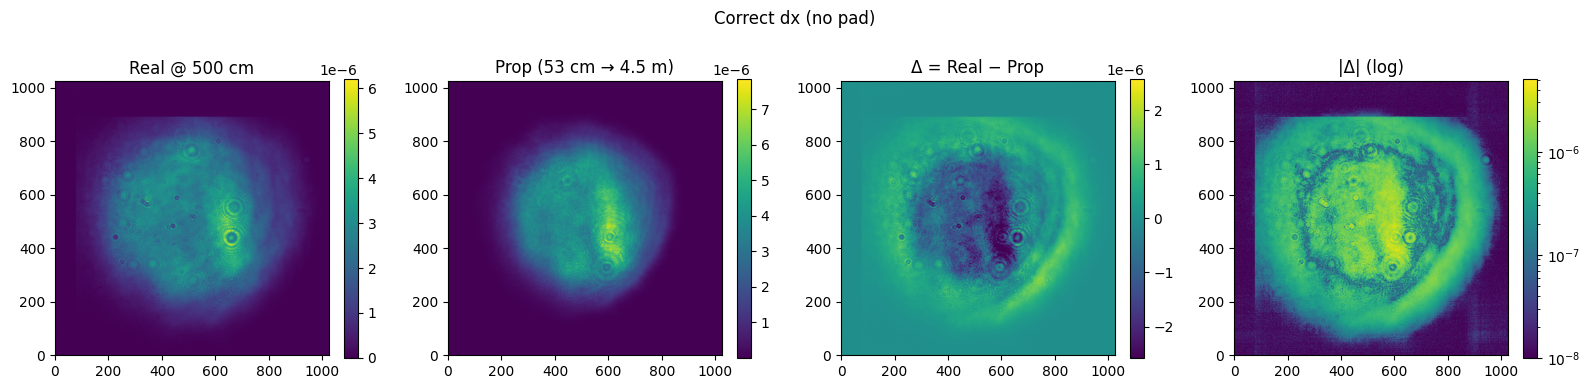


[dx + padding (pad=2)]
  ALL : MAE=3.843e-07, RMSE=6.361e-07, Max|Δ|=5.077e-06, relL2=0.4251, Corr=0.9282
  BEAM: MAE=5.347e-07, RMSE=7.52e-07, Max|Δ|=5.077e-06, relL2=0.4251, Corr=0.9229


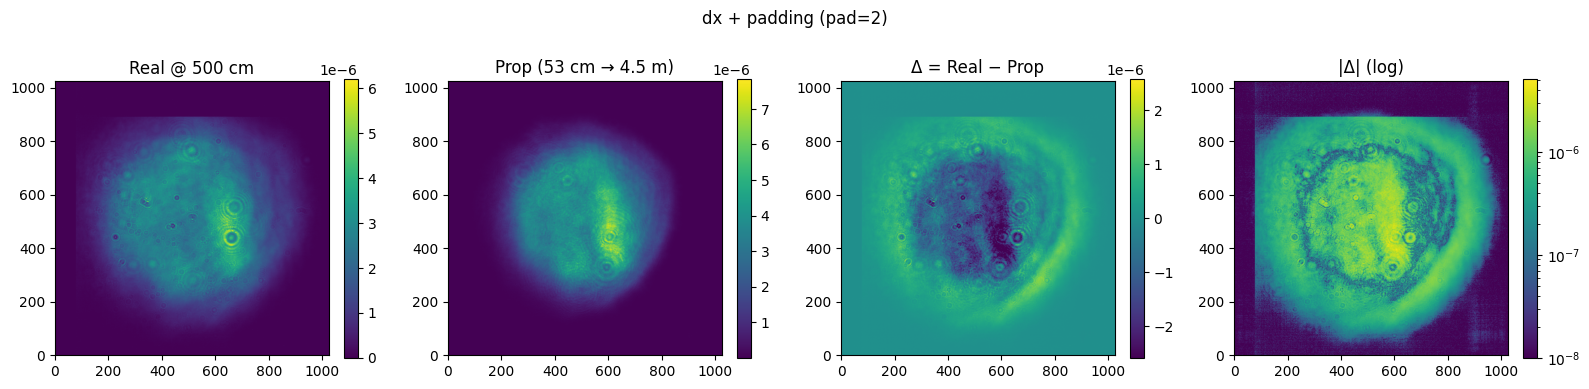


[dx + pad + power start (pad=2)]
  ALL : MAE=3.843e-07, RMSE=6.361e-07, Max|Δ|=5.077e-06, relL2=0.4251, Corr=0.9282
  BEAM: MAE=5.347e-07, RMSE=7.52e-07, Max|Δ|=5.077e-06, relL2=0.4251, Corr=0.9229


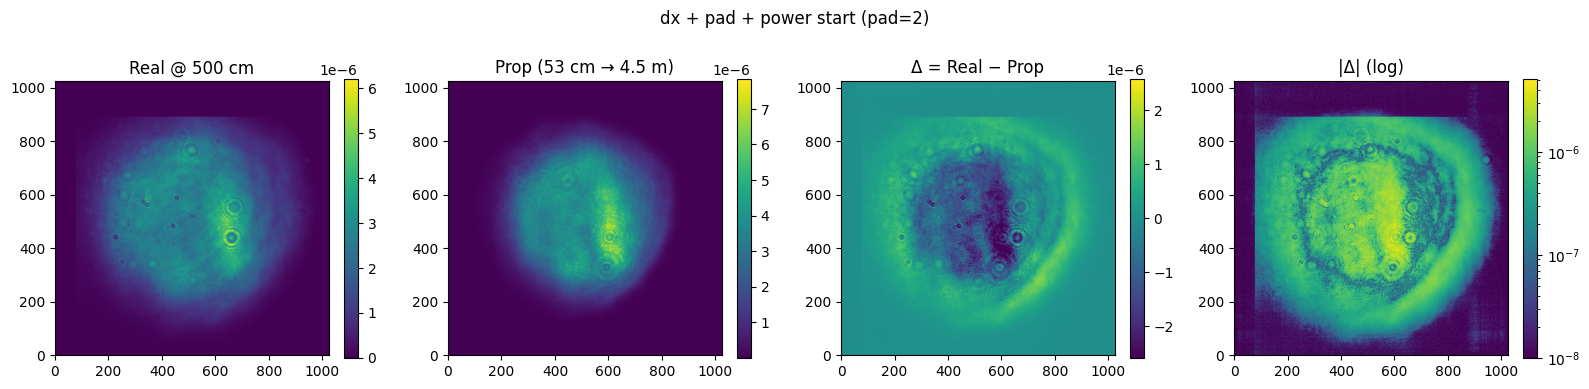

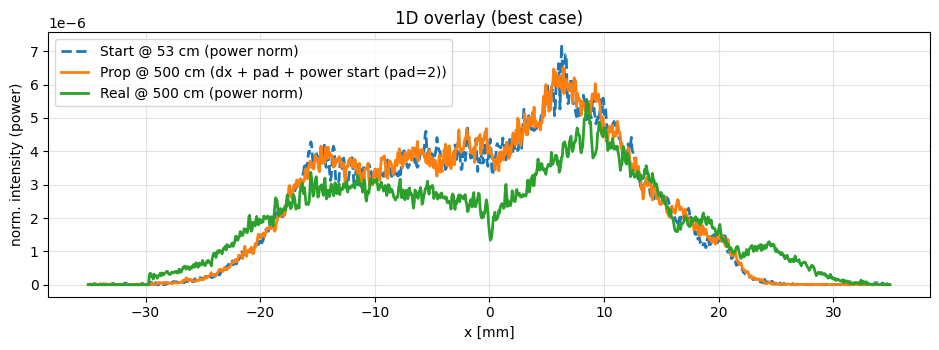

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

# ==============================================================
# CONFIG (anpassen!)
# ==============================================================
LAM = 800e-9
N = 1024

FILE_53CM  = "messung 53cm.tiff"
FILE_500CM = "messung 500cm.tiff"   # ggf. anpassen!
Z_PROP = 4.5                        # 53 cm -> +4.5 m ~ 500 cm

# "Alt" (künstlich) wie früher
BEAM_DIAM = 11e-3
L_OLD = 6 * BEAM_DIAM
DX_OLD = L_OLD / N

# "Neu" (physikalisch): Kamera Field-of-View Breite in mm einstellen!
FOV_MM = 70.0                       # <-- WICHTIG: reale Bildbreite (mm) deiner Messung
L_NEW = FOV_MM * 1e-3
DX_NEW = L_NEW / N

PAD_FACTOR = 2                      # 2 oder 4

CENTER_IMAGES = True
SUBTRACT_BG = True
BG_EDGE_FRAC = 0.03
CENTROID_THRESH_REL = 0.2

# Beam-Maske für Metriken (auf Realbild definiert)
BEAM_MASK_THR_REL = 1e-3            # 0.1% vom Peak

# ==============================================================
# Load + Preprocess
# ==============================================================
def load_tiff_gray(filename: str) -> np.ndarray:
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")
    try:
        import tifffile
        img = tifffile.imread(filename)
    except Exception:
        from PIL import Image
        img = np.array(Image.open(filename))

    img = np.asarray(img)
    if img.ndim == 3:
        if img.shape[-1] in (3, 4):
            img = img[..., :3].mean(axis=-1)
        else:
            img = img[0]
    return img.astype(np.float64)

def resample_bilinear(img, new_h, new_w):
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

def center_by_centroid(I, thresh_rel=0.2):
    I = np.asarray(I, float)
    if I.max() <= 0:
        return I
    t = thresh_rel * I.max()
    m = I > t
    if not np.any(m):
        return I

    yy, xx = np.indices(I.shape)
    cx = (xx[m] * I[m]).sum() / (I[m].sum() + 1e-12)
    cy = (yy[m] * I[m]).sum() / (I[m].sum() + 1e-12)

    sx = int(round(I.shape[1] / 2 - cx))
    sy = int(round(I.shape[0] / 2 - cy))
    return np.roll(np.roll(I, sy, axis=0), sx, axis=1)

def preprocess_intensity(I, center=True, subtract_bg=True, edge_frac=0.03):
    I = I.astype(np.float64)

    if subtract_bg:
        edge = max(10, int(edge_frac * min(I.shape)))
        border = np.concatenate([
            I[:edge, :].ravel(),
            I[-edge:, :].ravel(),
            I[:, :edge].ravel(),
            I[:, -edge:].ravel(),
        ])
        bg = np.median(border)
        I = I - bg
        I[I < 0] = 0.0

    if center:
        I = center_by_centroid(I, thresh_rel=CENTROID_THRESH_REL)

    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)

    return I

def normalize_peak(I):
    mx = I.max()
    return I / mx if mx > 0 else I

def normalize_power(I):
    s = I.sum()
    return I / s if s > 0 else I

# ==============================================================
# ASM propagation (with padding to avoid wrap-around)
# ==============================================================
def propagate_asm(U0, z, dx):
    fx = np.fft.fftfreq(U0.shape[0], d=dx)
    FX, FY = np.meshgrid(fx, fx)
    k0 = 2*np.pi / LAM
    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k0**2 - kx**2 - ky**2 + 0j)
    return np.fft.ifft2(np.fft.fft2(U0) * np.exp(1j * kz * z))

def propagate_asm_padded(U0, z, dx, pad_factor=2):
    if z == 0:
        return U0
    n = U0.shape[0]
    n2 = int(pad_factor * n)
    if n2 == n:
        return propagate_asm(U0, z, dx)

    s = (n2 - n) // 2
    U = np.zeros((n2, n2), dtype=np.complex128)
    U[s:s+n, s:s+n] = U0

    fx = np.fft.fftfreq(n2, d=dx)
    FX, FY = np.meshgrid(fx, fx)
    k0 = 2*np.pi / LAM
    kx = 2*np.pi * FX
    ky = 2*np.pi * FY
    kz = np.sqrt(k0**2 - kx**2 - ky**2 + 0j)

    Uz = np.fft.ifft2(np.fft.fft2(U) * np.exp(1j * kz * z))
    return Uz[s:s+n, s:s+n]

# ==============================================================
# 2D Comparison (metrics + diff plots)
# ==============================================================
def beam_mask(I, thr_rel=1e-3):
    mx = I.max() if I.max() > 0 else 1.0
    return I > thr_rel * mx

def metrics_2d(I_real, I_prop, mask=None):
    I_real = np.asarray(I_real, float)
    I_prop = np.asarray(I_prop, float)
    if mask is None:
        mask = np.ones_like(I_real, dtype=bool)

    a = I_real[mask].ravel()
    b = I_prop[mask].ravel()
    d = b - a

    mae = np.mean(np.abs(d))
    rmse = np.sqrt(np.mean(d**2))
    maxabs = np.max(np.abs(d))
    relL2 = np.linalg.norm(d) / (np.linalg.norm(a) + 1e-12)

    a0 = a - a.mean()
    b0 = b - b.mean()
    corr = (a0 @ b0) / (np.linalg.norm(a0)*np.linalg.norm(b0) + 1e-12)

    return {"MAE": mae, "RMSE": rmse, "Max|Δ|": maxabs, "relL2": relL2, "Corr": corr}

def plot_diff_maps(I_real, I_prop, title="", eps=1e-8):
    diff = I_real - I_prop
    absdiff = np.abs(diff)
    vmax = np.percentile(absdiff, 99.5) + 1e-12

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    im0 = ax[0].imshow(I_real, origin="lower")
    ax[0].set_title("Real @ 500 cm")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(I_prop, origin="lower")
    ax[1].set_title("Prop (53 cm → 4.5 m)")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", vmin=-vmax, vmax=vmax)
    ax[2].set_title("Δ = Real − Prop")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    im3 = ax[3].imshow(np.maximum(absdiff, eps), origin="lower",
                       norm=LogNorm(vmin=eps, vmax=max(np.max(absdiff), eps)))
    ax[3].set_title("|Δ| (log)")
    plt.colorbar(im3, ax=ax[3], fraction=0.046)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ==============================================================
# Main: build prop cases with incremental fixes and compare to 500cm
# ==============================================================
if __name__ == "__main__":
    print("=== Loading images ===")
    I53_raw = load_tiff_gray(FILE_53CM)
    I500_raw = load_tiff_gray(FILE_500CM)

    I53 = preprocess_intensity(I53_raw, center=CENTER_IMAGES, subtract_bg=SUBTRACT_BG, edge_frac=BG_EDGE_FRAC)
    I500 = preprocess_intensity(I500_raw, center=CENTER_IMAGES, subtract_bg=SUBTRACT_BG, edge_frac=BG_EDGE_FRAC)

    # For comparison to real @500cm, pick ONE normalization and keep it consistent.
    # Here: power normalization is recommended.
    I53n = normalize_power(I53)
    I500n = normalize_power(I500)

    # Build reference mask from real 500cm
    mask_beam = beam_mask(I500n, thr_rel=BEAM_MASK_THR_REL)

    # Build field from 53cm intensity (phase=0)
    U0_peak = np.sqrt(np.maximum(normalize_peak(I53), 0.0)).astype(np.complex128)
    U0_pow  = np.sqrt(np.maximum(I53n, 0.0)).astype(np.complex128)

    # ---- CASES: each returns I_prop (2D) to be compared to I500n ----
    cases = []

    # 1) Original: old dx, no padding, peak normalization
    Uz = propagate_asm(U0_peak, Z_PROP, DX_OLD)
    Iprop = normalize_power(np.abs(Uz)**2)  # compare using power norm
    cases.append(("Original (old dx, no pad, peak->power)", Iprop))

    # 2) Correct dx: new dx, no padding
    Uz = propagate_asm(U0_peak, Z_PROP, DX_NEW)
    Iprop = normalize_power(np.abs(Uz)**2)
    cases.append(("Correct dx (no pad)", Iprop))

    # 3) dx + padding
    Uz = propagate_asm_padded(U0_peak, Z_PROP, DX_NEW, pad_factor=PAD_FACTOR)
    Iprop = normalize_power(np.abs(Uz)**2)
    cases.append((f"dx + padding (pad={PAD_FACTOR})", Iprop))

    # 4) dx + pad + power-normalized start
    Uz = propagate_asm_padded(U0_pow, Z_PROP, DX_NEW, pad_factor=PAD_FACTOR)
    Iprop = normalize_power(np.abs(Uz)**2)
    cases.append((f"dx + pad + power start (pad={PAD_FACTOR})", Iprop))

    # ---- Compare ALL cases to real @500cm ----
    print("\n===== 2D Vergleich: Prop(53→4.5m) vs Real(500cm) =====")
    for name, Iprop in cases:
        m_all  = metrics_2d(I500n, Iprop, mask=None)
        m_beam = metrics_2d(I500n, Iprop, mask=mask_beam)

        print(f"\n[{name}]")
        print("  ALL : " + ", ".join([f"{k}={v:.4g}" for k,v in m_all.items()]))
        print("  BEAM: " + ", ".join([f"{k}={v:.4g}" for k,v in m_beam.items()]))

        plot_diff_maps(I500n, Iprop, title=name)

    # Also show a quick 1D overlay for the best case (last one)
    best_name, best_Iprop = cases[-1]
    mid = N // 2
    x_mm = (np.arange(N) - N/2) * DX_NEW * 1e3

    plt.figure(figsize=(9.5, 3.6))
    plt.plot(x_mm, I53n[mid, :], "--", linewidth=2, label="Start @ 53 cm (power norm)")
    plt.plot(x_mm, best_Iprop[mid, :], linewidth=2, label=f"Prop @ 500 cm ({best_name})")
    plt.plot(x_mm, I500n[mid, :], linewidth=2, label="Real @ 500 cm (power norm)")
    plt.xlabel("x [mm]")
    plt.ylabel("norm. intensity (power)")
    plt.title("1D overlay (best case)")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.show()
